# Binary Classification using Deep Neural Network (IMDB Dataset)

This notebook performs Binary Classification on movie reviews using a Deep Neural Network (DNN).

Dataset Used: IMDB Movie Reviews Dataset


In [2]:
# Import Required Libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [4]:
df = pd.read_csv(
    "IMDB_Dataset.csv",
    encoding_errors='ignore',
    on_bad_lines='skip',
    engine='python'
)

In [5]:
# Convert Sentiment into Numbers
df = df.dropna()
df.columns = ['review', 'sentiment']
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [6]:
# Split Dataset

X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [8]:
# Convert Text Data into Numerical Data using TF-IDF

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words='english'
)


X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()

print("Training Data Shape:", X_train_tfidf.shape)
print("Testing Data Shape:", X_test_tfidf.shape)


Training Data Shape: (40000, 10000)
Testing Data Shape: (10000, 10000)


In [9]:
# Build Deep Neural Network Model

model = Sequential()

model.add(Dense(128, activation='relu',input_shape=(X_train_tfidf.shape[1],)))
model.add(Dense(62, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show Model Summary
model.summary()


C:\Users\Arclooks\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │       1,280,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 62)                  │           7,998 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              63 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,288,189 (4.91 MB)

 Trainable params: 1,288,189 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train the Model

history = model.fit(
    X_train_tfidf,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.8668 - loss: 0.3185 - val_accuracy: 0.8829 - val_loss: 0.2763
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9280 - loss: 0.1861 - val_accuracy: 0.8806 - val_loss: 0.3012
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9599 - loss: 0.1033 - val_accuracy: 0.8737 - val_loss: 0.3613
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9888 - loss: 0.0316 - val_accuracy: 0.8731 - val_loss: 0.5693
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.9972 - loss: 0.0079 - val_accuracy: 0.8696 - val_loss: 0.7459


In [12]:
# Evaluate Model

loss, accuracy = model.evaluate(X_test_tfidf, y_test)

print("Test Accuracy:", accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8720 - loss: 0.7319
Test Accuracy: 0.871999979019165


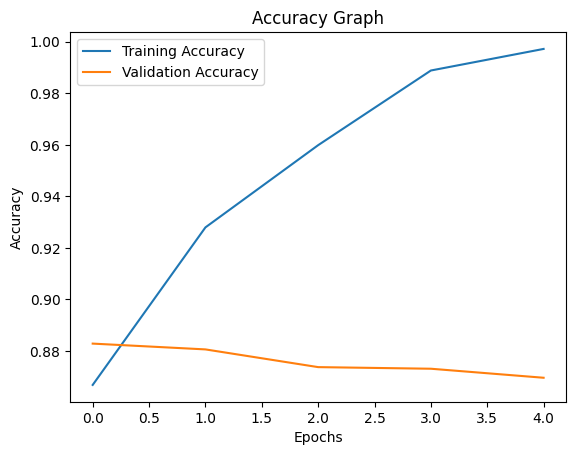

In [13]:
# Plot Accuracy Graph

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [14]:
# Test Custom Review

review = ["This movie is very good"]

review_tfidf = tfidf.transform(review).toarray()

result = model.predict(review_tfidf)

if result > 0.5:
    print("Positive Review")
else:
    print("Negative Review")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Positive Review


# Conclusion

- Successfully implemented Binary Classification using Deep Neural Network.
- Used TF-IDF for text preprocessing.
- Used Dense layers for classification.
- Predicted positive and negative movie reviews.
